# **AA1 COMPETITON PROJECT**
## **1. PREPROCESSING**
### **1.1 Imports**

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 20)

### **1.2 Loading the data**

In [8]:
train = pd.read_csv('train_nt.csv', sep=';', index_col=0)
test  = pd.read_csv('test_nolabels_nt.csv', sep=';', index_col=0)

print(f'Train shape: {train.shape}')  
print(f'Test shape:  {test.shape}')  

Train shape: (12888, 261)
Test shape:  (3223, 260)


Reflexio


### **1.3 Basic data inspection**

In [10]:
train.head()

,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,Q2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
ID,,,,,,,,,,,,,,,,,,,,,
0,0,-5703,-88,-88,0,0,4,5,7,8,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,0,1835,-91,-88,0,0,-10,4,-7,3,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,0,4,-86,-87,0,0,5,14,5,5,...,10,7,16,7,13,11,16,11,13,9
3,52464,1259,-81,-71,0,0,-1,12,1,11,...,13,-7,14,-6,17,-6,16,-7,16,2
4,0,900,-82,-76,0,0,9,2,9,-3,...,6,14,4,16,7,14,7,14,2,2


In [12]:
train.dtypes.value_counts()

int64    261
Name: count, dtype: int64

In [ ]:
# Missing values
print('Train NaN:', train.isnull().sum().sum())
print('Test  NaN:', test.isnull().sum().sum())

Train NaN: 0
Test  NaN: 0


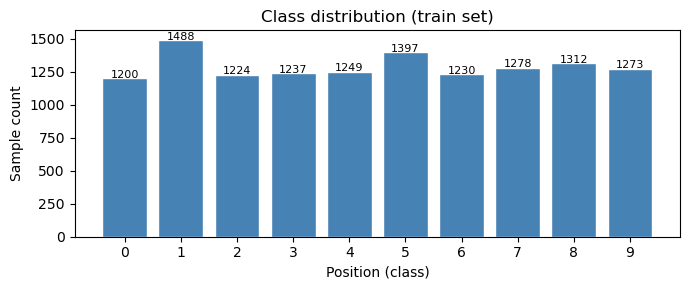

position
0    1200
1    1488
2    1224
3    1237
4    1249
5    1397
6    1230
7    1278
8    1312
9    1273
Name: count, dtype: int64


In [14]:
# Target distribution
fig, ax = plt.subplots(figsize=(7, 3))
counts = train['position'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Position (class)')
ax.set_ylabel('Sample count')
ax.set_title('Class distribution (train set)')
ax.set_xticks(range(10))
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)

In [16]:
# Non-CSI features
train[['seq_ctrl', 'aoa', 'rssi1', 'rssi2']].describe()

,seq_ctrl,aoa,rssi1,rssi2
count,12888.000,12888.000,12888.000,12888.000
mean,16008.410,15.017,-78.052,-77.952
std,19829.509,3087.311,6.805,8.349
min,0.000,-8703.000,-97.000,-94.000
25%,0.000,-1751.000,-83.000,-84.000
50%,5464.000,-30.000,-80.000,-80.000
75%,29424.000,1798.000,-74.000,-71.000
max,65520.000,8915.000,-58.000,-58.000


reflexio
